# Paper alignment — Pingitore et al., *IJC* 404 (2024) 131981

**Scope.** Retrace the *methodological steps* of

> Pingitore et al., "Machine learning to identify a composite indicator to
> predict cardiac death in ischemic heart disease", *International Journal of
> Cardiology* 404 (2024) 131981,

on the project's **strict** cohort, so the thesis results (extension with
thyroid function) become **comparable** with that paper.

The goal is **not** to reproduce the same numbers, but to **retrace the same
steps while being explicit about the differences**. Everything below reuses the
existing cohort construction and feature engineering (`configs`, `src.features`,
`src.preprocessing`) — no dataset, cohort, module or report is modified. The
heavy computation lives in `src.alignment.run_alignment` (cached under
`reports/alignment/`); this notebook only orchestrates and displays.

**Key differences vs the paper** (detailed in §6):
- Cohort: **strict only**.
- CV17 stays at **17 cardiac variables**; **creatinine / eGFR remain EXCLUDED**
  (too many missing). The paper used 18 variables incl. creatinine — documented,
  not added.
- Validation: the repo's **5-fold CV (A)** *and* a **new 60/20/20 holdout (B)**.
- Thyroid states encoded as **5 dummies** (eutiroideo = reference).
- Horizons: **7 and 10 years**.


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from configs.config import RANDOM_STATE
from src.alignment.cohorts10 import build_strict_cohorts, summarize
from src.alignment.features_align import (
    describe_feature_sets, extract_Xy_align, get_align_feature_set,
)
from src.alignment.holdout_split import split_60_20_20, describe_split
from src.alignment.ensemble import ALIGN_MODELS, ENSEMBLE_MEMBERS
from src.alignment import run_alignment as RA

# ── parameters ──
SEED      = RANDOM_STATE
HORIZONS  = (7, 10)
N_BOOT    = 1000
# Set FORCE=True to recompute caches from scratch (slow: full model grid incl.
# SVC/MLP for 8 sets x 2 horizons x 2 schemes). Default reads reports/alignment/.
FORCE     = False

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
print("Models reported:", ALIGN_MODELS)
print("Ensemble members (mean of probabilities):", ENSEMBLE_MEMBERS)


Models reported: ['LogisticRegression', 'RandomForest', 'AdaBoost', 'SVC', 'KNeighbors', 'MLP', 'GradientBoosting', 'XGBoost', 'ENSEMBLE']
Ensemble members (mean of probabilities): ['LogisticRegression', 'RandomForest', 'AdaBoost']


## 0. Cohorts and feature sets (verification)

We rebuild the **strict** cohort at **7 and 10 years** with the *same logic* as
`build_dataset` (only the horizon changes). The 7-year cohort is asserted to be
identical to the saved `cohort_strict.parquet`. For every feature set we print
the exact feature list used in this notebook.

In [2]:
cohorts = build_strict_cohorts(HORIZONS)

# Verify the rebuilt 7y strict cohort matches the saved one.
saved = pd.read_parquet(ROOT / "data" / "processed" / "cohort_strict.parquet")
assert len(cohorts[7]) == len(saved), "7y N mismatch vs saved strict cohort"
assert int(cohorts[7]["y7"].sum()) == int(saved["y7"].sum()), "7y events mismatch"
print("OK: rebuilt 7y strict cohort matches saved cohort_strict.parquet")

summ = pd.DataFrame([summarize(cohorts[h], h) for h in HORIZONS])
display(Markdown("**Strict cohort — N, events (CVD death), prevalence**"))
display(summ)


OK: rebuilt 7y strict cohort matches saved cohort_strict.parquet


**Strict cohort — N, events (CVD death), prevalence**

,horizon_years,N,n_events_cvd,n_survivors,prevalence
0,7,4390,843,3547,0.192
1,10,2614,962,1652,0.368


In [3]:
display(Markdown("**Feature sets used in this notebook** "
                 "(5-dummy thyroid states, eutiroideo = reference)"))
display(describe_feature_sets())


**Feature sets used in this notebook** (5-dummy thyroid states, eutiroideo = reference)

,feature_set,n_features,features
0,CV17,17,"Gender, Age, Angina, Previous_CABG, Previous_P..."
1,CV17_THY26,25,"Gender, Age, Angina, Previous_CABG, Previous_P..."
2,CV17_BIN,18,"Gender, Age, Angina, Previous_CABG, Previous_P..."
3,CV17_ORD,18,"Gender, Age, Angina, Previous_CABG, Previous_P..."
4,CV17_CONT,20,"Gender, Age, Angina, Previous_CABG, Previous_P..."
5,CV17_CAT,22,"Gender, Age, Angina, Previous_CABG, Previous_P..."
6,CV17_RATIO,26,"Gender, Age, Angina, Previous_CABG, Previous_P..."
7,CV17_RATIO_ONLY,21,"Gender, Age, Angina, Previous_CABG, Previous_P..."


In [4]:
# Illustrate the 60/20/20 stratified split (scheme B) on CV17 @ 7y.
Xb, yb = extract_Xy_align(cohorts[7], "CV17", "y7")
itr, iva, ite = split_60_20_20(yb, seed=SEED)
display(Markdown("**Scheme B — 60/20/20 stratified split (CV17 @ 7y)**"))
display(describe_split(yb, itr, iva, ite))


**Scheme B — 60/20/20 stratified split (CV17 @ 7y)**

,part,n,fraction,n_pos,prevalence
0,train,2634,0.6,506,0.1921
1,val,878,0.2,169,0.1925
2,test,878,0.2,168,0.1913


## 1. Classification — paper-like baseline + ensemble

All models (LogisticRegression, RF, AdaBoost — the ensemble members — plus SVC,
k-NN, MLP, GradientBoosting, XGBoost) and the **ENSEMBLE** (mean of LR+RF+AdaBoost
probabilities), on the strict cohort. Pipeline is leakage-free
(`SimpleImputer → StandardScaler → RandomOverSampler → estimator`). Decision
threshold maximises F1-macro (tuned on inner-validation in A, on the validation
split in B).

Reported for **both schemes** (A: 5-fold CV mean±sd; B: 60/20/20 test) and
**both horizons** (7, 10): F1-macro (primary), AUROC, precision/recall, Brier.

In [5]:
clf = RA.build_classification_table(cohorts, horizons=HORIZONS, seed=SEED, force=FORCE)
print("classification rows:", len(clf))

def clf_view(scheme, horizon, metrics=("f1_macro", "roc_auc", "precision_1",
                                       "recall_1", "brier")):
    sub = clf[(clf["scheme"] == scheme) & (clf["horizon"] == horizon)].copy()
    piv = sub.pivot_table(index="feature_set", columns="model",
                          values="f1_macro")
    return sub, piv

for h in HORIZONS:
    for scheme, label in [("A_5fold_cv", "A · 5-fold CV"),
                          ("B_60_20_20", "B · 60/20/20 test")]:
        sub = clf[(clf["scheme"] == scheme) & (clf["horizon"] == h)]
        display(Markdown(f"### Classification — strict cohort, {h}y, scheme {label}"))
        cols = ["feature_set", "model", "f1_macro", "roc_auc",
                "precision_1", "recall_1", "precision_0", "recall_0", "brier"]
        display(sub[cols].round(3).reset_index(drop=True))


classification rows: 288


### Classification — strict cohort, 7y, scheme A · 5-fold CV

,feature_set,model,f1_macro,roc_auc,precision_1,recall_1,precision_0,recall_0,brier
0,CV17,LogisticRegression,0.731,0.840,0.541,0.612,0.905,0.874,0.162
1,CV17,RandomForest,0.707,0.816,0.500,0.594,0.899,0.856,0.123
2,CV17,AdaBoost,0.720,0.833,0.536,0.572,0.897,0.882,0.196
3,CV17,SVC,0.715,0.816,0.517,0.581,0.897,0.869,0.153
4,CV17,KNeighbors,0.640,0.710,0.395,0.491,0.871,0.818,0.216
...,...,...,...,...,...,...,...,...,...
67,CV17_RATIO_ONLY,KNeighbors,0.637,0.719,0.411,0.472,0.869,0.829,0.207
68,CV17_RATIO_ONLY,MLP,0.686,0.786,0.485,0.539,0.888,0.858,0.156
69,CV17_RATIO_ONLY,GradientBoosting,0.724,0.837,0.557,0.556,0.895,0.894,0.149
70,CV17_RATIO_ONLY,XGBoost,0.718,0.817,0.535,0.561,0.895,0.884,0.133


### Classification — strict cohort, 7y, scheme B · 60/20/20 test

,feature_set,model,f1_macro,roc_auc,precision_1,recall_1,precision_0,recall_0,brier
0,CV17,LogisticRegression,0.744,0.838,0.617,0.548,0.896,0.920,0.161
1,CV17,RandomForest,0.718,0.830,0.553,0.530,0.890,0.899,0.118
2,CV17,AdaBoost,0.715,0.824,0.593,0.476,0.882,0.923,0.197
3,CV17,SVC,0.726,0.826,0.520,0.625,0.907,0.863,0.147
4,CV17,KNeighbors,0.671,0.745,0.444,0.518,0.881,0.846,0.199
...,...,...,...,...,...,...,...,...,...
67,CV17_RATIO_ONLY,KNeighbors,0.655,0.759,0.389,0.655,0.903,0.756,0.188
68,CV17_RATIO_ONLY,MLP,0.733,0.815,0.587,0.542,0.893,0.910,0.146
69,CV17_RATIO_ONLY,GradientBoosting,0.745,0.833,0.622,0.548,0.896,0.921,0.148
70,CV17_RATIO_ONLY,XGBoost,0.733,0.833,0.530,0.637,0.910,0.866,0.125


### Classification — strict cohort, 10y, scheme A · 5-fold CV

,feature_set,model,f1_macro,roc_auc,precision_1,recall_1,precision_0,recall_0,brier
0,CV17,LogisticRegression,0.761,0.852,0.721,0.682,0.821,0.838,0.156
1,CV17,RandomForest,0.751,0.836,0.690,0.697,0.824,0.809,0.157
2,CV17,AdaBoost,0.753,0.837,0.689,0.686,0.818,0.819,0.193
3,CV17,SVC,0.754,0.840,0.689,0.689,0.819,0.818,0.160
4,CV17,KNeighbors,0.697,0.764,0.601,0.662,0.791,0.743,0.203
...,...,...,...,...,...,...,...,...,...
67,CV17_RATIO_ONLY,KNeighbors,0.698,0.763,0.604,0.657,0.790,0.748,0.203
68,CV17_RATIO_ONLY,MLP,0.754,0.841,0.700,0.689,0.820,0.820,0.161
69,CV17_RATIO_ONLY,GradientBoosting,0.765,0.852,0.706,0.703,0.828,0.828,0.154
70,CV17_RATIO_ONLY,XGBoost,0.746,0.835,0.678,0.698,0.821,0.798,0.162


### Classification — strict cohort, 10y, scheme B · 60/20/20 test

,feature_set,model,f1_macro,roc_auc,precision_1,recall_1,precision_0,recall_0,brier
0,CV17,LogisticRegression,0.763,0.853,0.670,0.760,0.849,0.782,0.164
1,CV17,RandomForest,0.742,0.835,0.634,0.766,0.845,0.743,0.159
2,CV17,AdaBoost,0.737,0.835,0.642,0.719,0.825,0.767,0.190
3,CV17,SVC,0.762,0.855,0.665,0.766,0.851,0.776,0.157
4,CV17,KNeighbors,0.702,0.788,0.705,0.510,0.755,0.876,0.193
...,...,...,...,...,...,...,...,...,...
67,CV17_RATIO_ONLY,KNeighbors,0.699,0.776,0.603,0.656,0.790,0.749,0.201
68,CV17_RATIO_ONLY,MLP,0.739,0.853,0.627,0.771,0.847,0.734,0.160
69,CV17_RATIO_ONLY,GradientBoosting,0.741,0.847,0.647,0.724,0.828,0.770,0.161
70,CV17_RATIO_ONLY,XGBoost,0.748,0.842,0.642,0.766,0.847,0.752,0.160


### ENSEMBLE — F1-macro / AUROC by feature set, scheme, horizon

f1_macro                                     roc_auc                                 
horizon                 7                     10                    7                     10           
scheme          A_5fold_cv B_60_20_20 A_5fold_cv B_60_20_20 A_5fold_cv B_60_20_20 A_5fold_cv B_60_20_20
feature_set                                                                                            
CV17                 0.731      0.748      0.768      0.753      0.842      0.843      0.854      0.850
CV17_BIN             0.722      0.718      0.763      0.763      0.842      0.844      0.855      0.853
CV17_CAT             0.724      0.748      0.768      0.745      0.842      0.843      0.855      0.853
CV17_CONT            0.736      0.744      0.772      0.748      0.845      0.845      0.857      0.853
CV17_ORD             0.725      0.763      0.773      0.758      0.843      0.842      0.855      0.851
CV17_RATIO           0.727      0.717      0.773      0.737      0.845      0.846      0.857      0.853
CV17_RATIO_ONLY      0.729      0.762      0.768      0.746      0.846      0.846      0.857      0.854
CV17_THY26           0.729      0.736      0.768      0.741      0.845      0.845      0.855      0.854

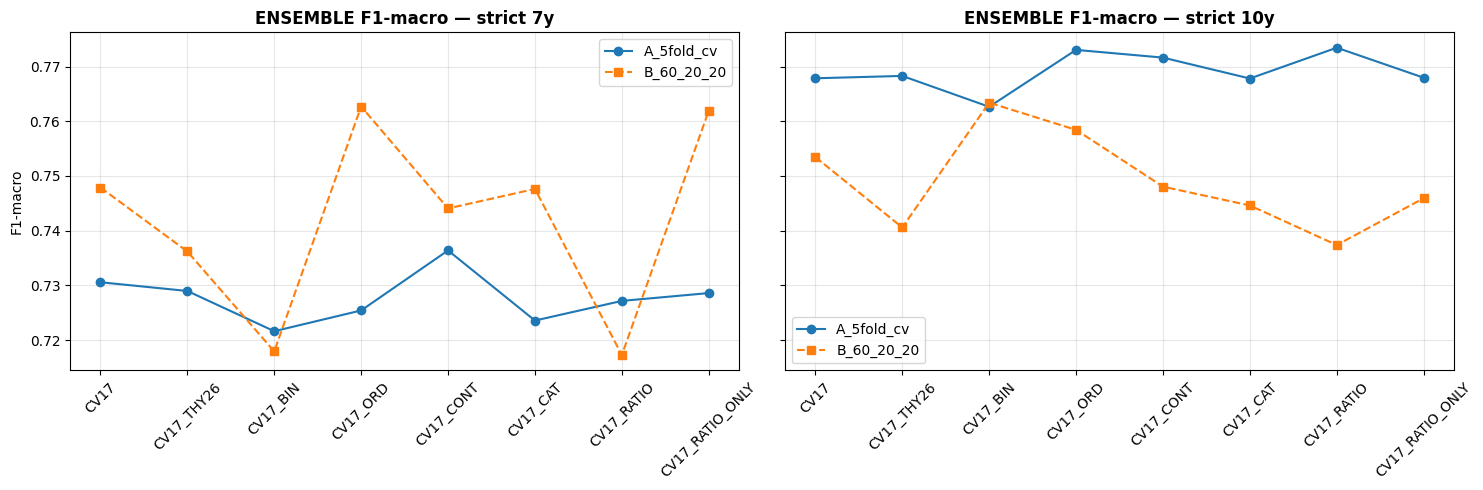

In [6]:
# Focus: ENSEMBLE across feature sets, both schemes, both horizons.
ens = clf[clf["model"] == "ENSEMBLE"].copy()
display(Markdown("### ENSEMBLE — F1-macro / AUROC by feature set, scheme, horizon"))
ens_tab = ens.pivot_table(index="feature_set",
                          columns=["horizon", "scheme"],
                          values=["f1_macro", "roc_auc"]).round(3)
display(ens_tab)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, h in zip(axes, HORIZONS):
    for scheme, mk in [("A_5fold_cv", "o-"), ("B_60_20_20", "s--")]:
        d = ens[(ens["horizon"] == h) & (ens["scheme"] == scheme)]
        d = d.set_index("feature_set").reindex(
            describe_feature_sets()["feature_set"])
        ax.plot(d.index, d["f1_macro"], mk, label=f"{scheme}")
    ax.set_title(f"ENSEMBLE F1-macro — strict {h}y", fontweight="bold")
    ax.tick_params(axis="x", rotation=45); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel("F1-macro")
fig.tight_layout(); plt.show()


## 2. Incremental value of thyroid vs CV17 (ensemble)

For each thyroid feature set **vs CV17**, on the **ENSEMBLE**, paired on the same
folds (A) / same split (B): **Δ F1-macro** and **Δ AUROC** with **95% bootstrap
CI**. A CI excluding 0 indicates a statistically meaningful change.

In [7]:
incr = RA.build_incremental_table(cohorts, horizons=HORIZONS,
                                  n_boot=N_BOOT, seed=SEED, force=FORCE)

def fmt_ci(row, point_col, ci_prefix):
    return (f"{row[point_col]:+.3f} "
            f"[{row[ci_prefix + '_ci_lo']:+.3f}, "
            f"{row[ci_prefix + '_ci_hi']:+.3f}]")

incr_disp = incr.copy()
incr_disp["ΔF1-macro [CI95]"] = incr_disp.apply(
    lambda r: fmt_ci(r, "delta_f1_macro", "delta_f1"), axis=1)
incr_disp["ΔAUROC [CI95]"]   = incr_disp.apply(
    lambda r: fmt_ci(r, "delta_auroc", "delta_auroc"), axis=1)
for h in HORIZONS:
    display(Markdown(f"### Incremental value vs CV17 — strict {h}y (ENSEMBLE)"))
    sub = incr_disp[incr_disp["horizon"] == h]
    display(sub[["feature_set", "scheme", "ΔF1-macro [CI95]",
                 "ΔAUROC [CI95]"]].reset_index(drop=True))


### Incremental value vs CV17 — strict 7y (ENSEMBLE)

,feature_set,scheme,ΔF1-macro [CI95],ΔAUROC [CI95]
0,CV17_THY26,A_5fold_cv,"+0.001 [-0.008, +0.011]","+0.003 [-0.000, +0.007]"
1,CV17_THY26,B_60_20_20,"+0.004 [-0.023, +0.029]","+0.002 [-0.007, +0.011]"
2,CV17_BIN,A_5fold_cv,"-0.002 [-0.009, +0.006]","+0.000 [-0.002, +0.003]"
3,CV17_BIN,B_60_20_20,"+0.002 [-0.016, +0.022]","+0.001 [-0.006, +0.008]"
4,CV17_ORD,A_5fold_cv,"-0.003 [-0.009, +0.002]","+0.002 [+0.000, +0.004]"
5,CV17_ORD,B_60_20_20,"+0.008 [-0.009, +0.024]","-0.001 [-0.005, +0.004]"
6,CV17_CONT,A_5fold_cv,"+0.005 [-0.003, +0.014]","+0.004 [+0.001, +0.008]"
7,CV17_CONT,B_60_20_20,"+0.016 [-0.006, +0.039]","+0.002 [-0.005, +0.010]"
8,CV17_CAT,A_5fold_cv,"-0.004 [-0.011, +0.004]","+0.000 [-0.002, +0.003]"
9,CV17_CAT,B_60_20_20,"+0.005 [-0.012, +0.022]","-0.000 [-0.006, +0.006]"


### Incremental value vs CV17 — strict 10y (ENSEMBLE)

,feature_set,scheme,ΔF1-macro [CI95],ΔAUROC [CI95]
0,CV17_THY26,A_5fold_cv,"+0.006 [-0.003, +0.016]","+0.002 [-0.002, +0.006]"
1,CV17_THY26,B_60_20_20,"+0.001 [-0.014, +0.018]","+0.003 [-0.004, +0.011]"
2,CV17_BIN,A_5fold_cv,"+0.002 [-0.005, +0.010]","+0.001 [-0.001, +0.003]"
3,CV17_BIN,B_60_20_20,"-0.000 [-0.016, +0.017]","+0.002 [-0.003, +0.008]"
4,CV17_ORD,A_5fold_cv,"+0.003 [-0.004, +0.010]","+0.001 [-0.001, +0.003]"
5,CV17_ORD,B_60_20_20,"-0.003 [-0.036, +0.029]","+0.000 [-0.004, +0.005]"
6,CV17_CONT,A_5fold_cv,"+0.005 [-0.003, +0.013]","+0.003 [-0.000, +0.006]"
7,CV17_CONT,B_60_20_20,"+0.002 [-0.014, +0.016]","+0.003 [-0.004, +0.009]"
8,CV17_CAT,A_5fold_cv,"+0.002 [-0.004, +0.009]","+0.002 [-0.000, +0.004]"
9,CV17_CAT,B_60_20_20,"-0.003 [-0.035, +0.032]","+0.002 [-0.002, +0.007]"


## 3. ML indicator in survival (replica of the paper's approach)

The ensemble's predicted probability is used as the **ML composite indicator**:
- predicted **risk** `p_event` (CVD death ≤ horizon) → **single covariate** in a
  Cox model → **C-index**;
- predicted **survival** `p_survive = 1 − p_event` → **KM stratification** at the
  paper's **0.6** threshold *and* a data-driven **median** threshold.

We compare **CV17** vs **CV17+thyroid** (here `CV17_THY26`) and report the
**Δ C-index**.

> **CAVEAT (estimando condizionale).** This survival runs on the **strict**
> cohort, i.e. selecting on the outcome (patients censored before the horizon are
> removed). The estimates are therefore *conditional* — consistent with the
> paper, but **different** from the competing-risk (Aalen–Johansen) survival used
> elsewhere in the thesis on the full cohort. It does **not** overwrite or
> contradict that analysis; it serves only the comparison with the paper.

In [8]:
cindex_df, km_df = RA.build_ml_indicator(cohorts, base="CV17",
                                         thy="CV17_THY26",
                                         horizons=HORIZONS, seed=SEED,
                                         force=FORCE)
display(Markdown("### Cox single-covariate C-index (ML indicator = p_event)"))
display(cindex_df.round(4))
display(Markdown("### KM stratification by predicted survival (0.6 and median)"))
display(km_df.round(4))


### Cox single-covariate C-index (ML indicator = p_event)

,horizon,scheme,feature_set,c_index,n,events
0,7,A,CV17,0.8107,4390.0,843.0
1,7,A,CV17_THY26,0.8146,4390.0,843.0
2,7,A,DELTA(CV17_THY26-CV17),0.0039,NaN,NaN
3,7,B,CV17,0.8204,878.0,168.0
4,7,B,CV17_THY26,0.8236,878.0,168.0
5,7,B,DELTA(CV17_THY26-CV17),0.0032,NaN,NaN
6,10,A,CV17,0.7924,2614.0,962.0
7,10,A,CV17_THY26,0.7948,2614.0,962.0
8,10,A,DELTA(CV17_THY26-CV17),0.0024,NaN,NaN
9,10,B,CV17,0.7890,523.0,192.0


### KM stratification by predicted survival (0.6 and median)

,horizon,scheme,feature_set,threshold_name,threshold,n_high,n_low,surv_high,surv_low,logrank_p
0,7,A,CV17,fixed_0.6,0.6000,2818,1572,0.9368,0.5770,0.0
1,7,A,CV17,median,0.6878,2195,2195,0.9572,0.6588,0.0
2,7,A,CV17_THY26,fixed_0.6,0.6000,2781,1609,0.9407,0.5786,0.0
3,7,A,CV17_THY26,median,0.6874,2195,2195,0.9540,0.6620,0.0
4,7,B,CV17,fixed_0.6,0.6000,551,327,0.9401,0.5872,0.0
5,7,B,CV17,median,0.6860,439,439,0.9544,0.6629,0.0
6,7,B,CV17_THY26,fixed_0.6,0.6000,557,321,0.9408,0.5794,0.0
7,7,B,CV17_THY26,median,0.6888,439,439,0.9522,0.6651,0.0
8,10,A,CV17,fixed_0.6,0.6000,1287,1327,0.8834,0.3881,0.0
9,10,A,CV17,median,0.5946,1307,1307,0.8806,0.3833,0.0


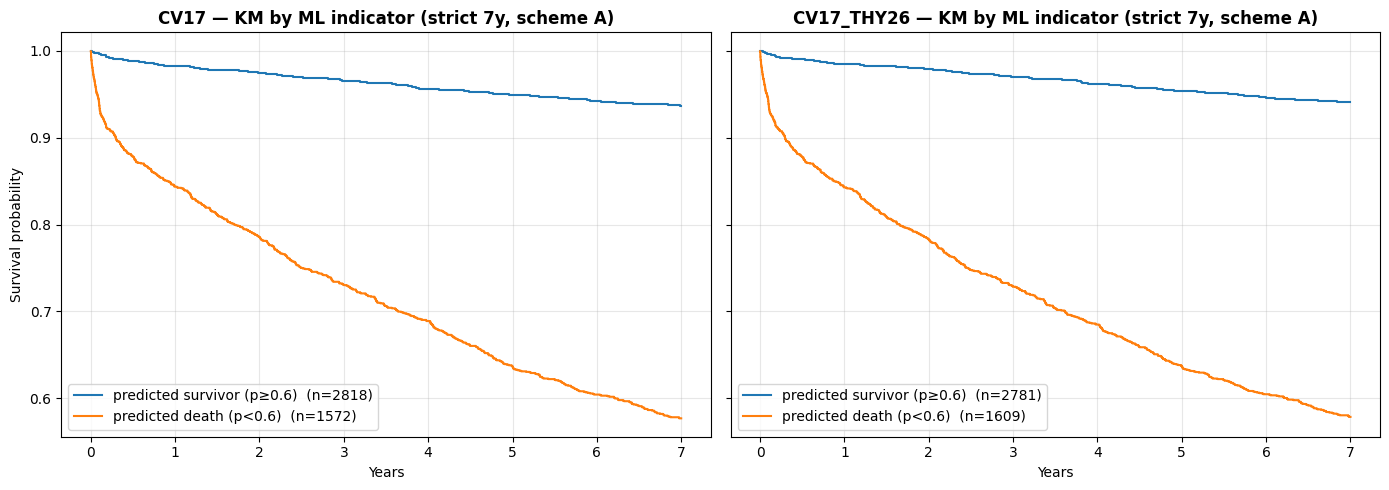

In [9]:
# KM curves for CV17 vs CV17_THY26 at the 0.6 threshold (scheme A, 7y).
from lifelines import KaplanMeierFitter
from src.alignment.ml_indicator import predicted_risk, _survival_frame

H = 7
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, fs in zip(axes, ["CV17", "CV17_THY26"]):
    risk = predicted_risk(cohorts[H], fs, f"y{H}", scheme="A", seed=SEED)
    surv = _survival_frame(cohorts[H], H)
    data = surv[["surv_time", "surv_event"]].join(risk["p_survive"],
                                                  how="inner").dropna()
    high = data["p_survive"] >= 0.6
    kmf = KaplanMeierFitter()
    for label, mask in [("predicted survivor (p≥0.6)", high),
                        ("predicted death (p<0.6)", ~high)]:
        if mask.sum():
            kmf.fit(data.loc[mask, "surv_time"], data.loc[mask, "surv_event"],
                    label=f"{label}  (n={int(mask.sum())})")
            kmf.plot_survival_function(ax=ax, ci_show=False)
    ax.set_title(f"{fs} — KM by ML indicator (strict {H}y, scheme A)",
                 fontweight="bold")
    ax.set_xlabel("Years"); ax.grid(alpha=0.3)
axes[0].set_ylabel("Survival probability")
fig.tight_layout(); plt.show()


## 4. Ablation test (paper style, extended to thyroid-derived features)

Knock-out: replace a feature with its (training) **mean**, recompute F1′ →
**importance = F1 / F1′** (>1 = useful, <1 = noise), on the trained ensemble.
**Single-variable** (one feature at a time) and **multi-variable** (thyroid
markers grouped by hierarchical clustering of their correlation; cardiac features
as singletons). Run for **every** feature set — answering *where do the thyroid
features sit among the predictors?*

In [10]:
abl = RA.build_ablation(cohorts, horizons=HORIZONS, seed=SEED, force=FORCE)
print("ablation rows:", len(abl))

# Single-variable ranking for the richest thyroid set, both horizons.
for h in HORIZONS:
    sub = abl[(abl["horizon"] == h) & (abl["feature_set"] == "CV17_THY26")
              & (abl["mode"] == "single")].copy()
    sub = sub.sort_values("importance", ascending=False)
    sub["rank"] = range(1, len(sub) + 1)
    display(Markdown(f"### Ablation (single) — CV17_THY26, strict {h}y "
                     "— thyroid rows highlighted"))
    display(sub[["rank", "feature", "importance", "is_thyroid"]]
            .round(4).reset_index(drop=True))


ablation rows: 660


### Ablation (single) — CV17_THY26, strict 7y — thyroid rows highlighted

,rank,feature,importance,is_thyroid
0,1,Age,1.1265,False
1,2,fe,1.0594,False
2,3,Dyslipidemia,1.0282,False
3,4,TSH,1.0194,True
4,5,Angiography,1.0155,False
5,6,Hypertension,1.0150,False
6,7,PostIsch_DCM,1.0134,False
7,8,Gender,1.0110,False
8,9,Acute_MI,1.0092,False
9,10,AFib,1.0090,False


### Ablation (single) — CV17_THY26, strict 10y — thyroid rows highlighted

,rank,feature,importance,is_thyroid
0,1,Age,1.0461,False
1,2,Diabetes,1.0062,False
2,3,Previous_PCI,1.0030,False
3,4,Angiography,1.0024,False
4,5,PostIsch_DCM,1.0024,False
5,6,Hypothyroid,1.0024,True
6,7,AFib,1.0019,False
7,8,Gender,1.0018,False
8,9,Hypertension,1.0000,False
9,10,SCH,1.0000,True


In [11]:
# Multi-variable (clustered) ablation for CV17_THY26.
for h in HORIZONS:
    sub = abl[(abl["horizon"] == h) & (abl["feature_set"] == "CV17_THY26")
              & (abl["mode"] == "multi")].copy()
    sub = sub.sort_values("importance", ascending=False)
    display(Markdown(f"### Ablation (multi-variable, clustered) — CV17_THY26, strict {h}y"))
    display(sub[["feature", "members", "importance", "is_thyroid"]]
            .round(4).reset_index(drop=True))


### Ablation (multi-variable, clustered) — CV17_THY26, strict 7y

,feature,members,importance,is_thyroid
0,Age,Age,1.1265,False
1,fe,fe,1.0594,False
2,Dyslipidemia,Dyslipidemia,1.0282,False
3,THY_cluster_4,TSH,1.0194,True
4,Angiography,Angiography,1.0155,False
5,Hypertension,Hypertension,1.0150,False
6,PostIsch_DCM,PostIsch_DCM,1.0134,False
7,Gender,Gender,1.0110,False
8,Acute_MI,Acute_MI,1.0092,False
9,AFib,AFib,1.0090,False


### Ablation (multi-variable, clustered) — CV17_THY26, strict 10y

,feature,members,importance,is_thyroid
0,Age,Age,1.0461,False
1,Diabetes,Diabetes,1.0062,False
2,Previous_PCI,Previous_PCI,1.0030,False
3,THY_cluster_7,Hypothyroid,1.0024,True
4,Angiography,Angiography,1.0024,False
5,PostIsch_DCM,PostIsch_DCM,1.0024,False
6,AFib,AFib,1.0019,False
7,Gender,Gender,1.0018,False
8,THY_cluster_2,SCH,1.0000,True
9,THY_cluster_6,Hyperthyroid,1.0000,True


In [12]:
# Where do thyroid features rank across ALL sets (single-variable)?
def thyroid_rank_summary(horizon):
    rows = []
    for fs in abl["feature_set"].unique():
        s = abl[(abl["horizon"] == horizon) & (abl["feature_set"] == fs)
                & (abl["mode"] == "single")].copy()
        if s.empty:
            continue
        s = s.sort_values("importance", ascending=False).reset_index(drop=True)
        s["rank"] = s.index + 1
        thy = s[s["is_thyroid"]]
        for _, r in thy.iterrows():
            rows.append({"feature_set": fs, "feature": r["feature"],
                         "rank": int(r["rank"]), "of": len(s),
                         "importance": round(r["importance"], 4)})
    return pd.DataFrame(rows)

for h in HORIZONS:
    display(Markdown(f"### Thyroid-feature placement in ablation ranking — strict {h}y"))
    display(thyroid_rank_summary(h))


### Thyroid-feature placement in ablation ranking — strict 7y

,feature_set,feature,rank,of,importance
0,CV17_THY26,TSH,4,25,1.0194
1,CV17_THY26,Low_T3,12,25,1.0074
2,CV17_THY26,SCT,18,25,1.0000
3,CV17_THY26,Hypothyroid,19,25,1.0000
4,CV17_THY26,fT3,20,25,0.9985
5,CV17_THY26,Hyperthyroid,21,25,0.9964
6,CV17_THY26,SCH,23,25,0.9930
7,CV17_THY26,fT4,24,25,0.9929
8,CV17_BIN,Thyroid_abnormal,7,18,1.0277
9,CV17_ORD,thyroid_ord,17,18,1.0000


### Thyroid-feature placement in ablation ranking — strict 10y

,feature_set,feature,rank,of,importance
0,CV17_THY26,Hypothyroid,6,25,1.0024
1,CV17_THY26,SCH,10,25,1.0000
2,CV17_THY26,Hyperthyroid,11,25,1.0000
3,CV17_THY26,Low_T3,12,25,0.9994
4,CV17_THY26,SCT,18,25,0.9958
5,CV17_THY26,TSH,21,25,0.9934
6,CV17_THY26,fT3,22,25,0.9893
7,CV17_THY26,fT4,23,25,0.9887
8,CV17_BIN,Thyroid_abnormal,10,18,1.0094
9,CV17_ORD,thyroid_ord,14,18,1.0024


## 5. Calibration / Brier

Brier score per model and for the ENSEMBLE (lower = better), under both schemes,
plus reliability curves for the ensemble and its members on CV17.

In [13]:
# Brier is already in the classification table; pivot it.
brier = clf.pivot_table(index=["horizon", "feature_set"],
                        columns=["model", "scheme"], values="brier")
display(Markdown("### Brier score by model / scheme (lower is better)"))
display(brier.round(3))


### Brier score by model / scheme (lower is better)

model                     AdaBoost              ENSEMBLE            GradientBoosting            KNeighbors            LogisticRegression             \
scheme                  A_5fold_cv B_60_20_20 A_5fold_cv B_60_20_20       A_5fold_cv B_60_20_20 A_5fold_cv B_60_20_20         A_5fold_cv B_60_20_20   
horizon feature_set                                                                                                                                   
7       CV17                 0.196      0.197      0.142      0.141            0.152      0.149      0.216      0.199              0.162      0.161   
        CV17_BIN             0.197      0.196      0.142      0.140            0.153      0.147      0.211      0.200              0.162      0.161   
        CV17_CAT             0.196      0.194      0.142      0.140            0.153      0.149      0.214      0.208              0.162      0.161   
        CV17_CONT            0.195      0.194      0.141      0.140            0.150      0.147      0.209      0.192              0.162      0.160   
        CV17_ORD             0.196      0.195      0.141      0.140            0.153      0.148      0.209      0.198              0.162      0.161   
        CV17_RATIO           0.196      0.198      0.142      0.140            0.149      0.147      0.212      0.205              0.162      0.160   
        CV17_RATIO_ONLY      0.196      0.198      0.141      0.140            0.149      0.148      0.207      0.188              0.161      0.160   
        CV17_THY26           0.195      0.194      0.141      0.139            0.149      0.147      0.211      0.207              0.162      0.161   
10      CV17                 0.193      0.190      0.156      0.159            0.157      0.163      0.203      0.193              0.156      0.164   
        CV17_BIN             0.193      0.191      0.156      0.158            0.157      0.161      0.201      0.208              0.156      0.163   
        CV17_CAT             0.194      0.190      0.156      0.158            0.156      0.164      0.202      0.208              0.156      0.163   
        CV17_CONT            0.193      0.193      0.156      0.159            0.154      0.161      0.202      0.202              0.156      0.164   
        CV17_ORD             0.193      0.190      0.156      0.159            0.156      0.164      0.199      0.201              0.156      0.164   
        CV17_RATIO           0.193      0.193      0.156      0.159            0.153      0.159      0.202      0.212              0.157      0.164   
        CV17_RATIO_ONLY      0.193      0.193      0.156      0.159            0.154      0.161      0.203      0.201              0.156      0.164   
        CV17_THY26           0.193      0.193      0.156      0.159            0.155      0.161      0.203      0.212              0.157      0.163   

model                          MLP            RandomForest                   SVC               XGBoost             
scheme                  A_5fold_cv B_60_20_20   A_5fold_cv B_60_20_20 A_5fold_cv B_60_20_20 A_5fold_cv B_60_20_20  
horizon feature_set                                                                                                
7       CV17                 0.162      0.163        0.123      0.118      0.153      0.147      0.141      0.134  
        CV17_BIN             0.161      0.153        0.121      0.116      0.150      0.143      0.140      0.135  
        CV17_CAT             0.158      0.158        0.121      0.116      0.149      0.144      0.141      0.134  
        CV17_CONT            0.157      0.147        0.116      0.114      0.150      0.146      0.135      0.128  
        CV17_ORD             0.163      0.147        0.120      0.115      0.150      0.146      0.141      0.136  
        CV17_RATIO           0.160      0.168        0.117      0.112      0.148      0.145      0.134      0.126  
        CV17_RATIO_ONLY      0.156      0.146        0.116      0.111      0.150      

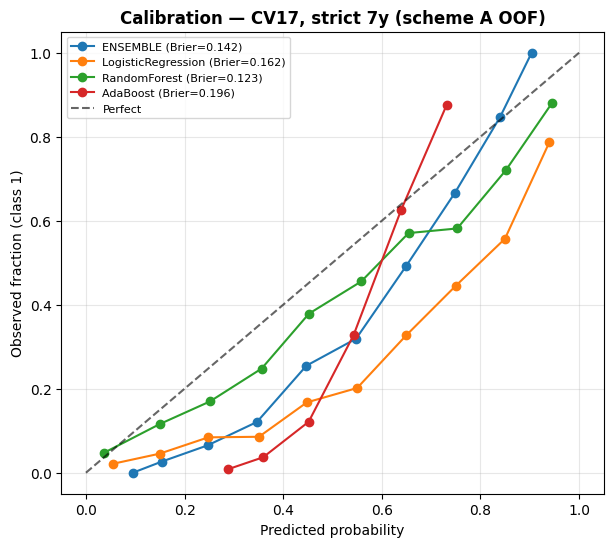

In [14]:
# Reliability curves: ensemble + members on CV17 @ 7y (scheme A OOF).
from src.alignment.evaluation import evaluate_cv
from src.alignment.calibration import plot_calibration

H = 7
X, y = extract_Xy_align(cohorts[H], "CV17", f"y{H}")
y_arr = np.asarray(pd.Series(np.asarray(y)))
curves = []
for m in ["ENSEMBLE"] + ENSEMBLE_MEMBERS:
    r = evaluate_cv(X, y, m, seed=SEED)
    curves.append((m, y_arr, r["oof_proba"]))

fig, ax = plt.subplots(figsize=(7, 6))
plot_calibration(ax, curves, f"Calibration — CV17, strict {H}y (scheme A OOF)")
plt.show()


## 6. Differences vs the paper

Declared differences (scope: **retrace the steps, not the numbers**).

In [15]:
diff = pd.DataFrame([
    ["Classification cohort", "3987 (757 CD)",
     f"strict {len(cohorts[7])} ({int(cohorts[7]['y7'].sum())} CVD ≤7y)"],
    ["Creatinine / eGFR", "included", "excluded (too many missing)"],
    ["Validation", "single 60/20/20 split", "5-fold CV + 60/20/20 split"],
    ["Non-CVD deaths", "excluded",
     "excluded in strict; competing elsewhere in the thesis"],
    ["Thyroid-state encoding", "—", "5 dummies (eutiroideo = reference)"],
    ["Horizons", "as in paper", "7 and 10 years"],
    ["Objective", "predict cardiac death",
     "incremental value of thyroid over CV17"],
], columns=["Aspect", "Paper (Pingitore 2024)", "This thesis"])
display(Markdown("### Declared differences vs the paper"))
display(diff)


### Declared differences vs the paper

,Aspect,Paper (Pingitore 2024),This thesis
0,Classification cohort,3987 (757 CD),strict 4390 (843 CVD ≤7y)
1,Creatinine / eGFR,included,excluded (too many missing)
2,Validation,single 60/20/20 split,5-fold CV + 60/20/20 split
3,Non-CVD deaths,excluded,excluded in strict; competing elsewhere in the...
4,Thyroid-state encoding,—,5 dummies (eutiroideo = reference)
5,Horizons,as in paper,7 and 10 years
6,Objective,predict cardiac death,incremental value of thyroid over CV17


## 7. Final synthesis

For each horizon and scheme: best CV17 baseline (ensemble), whether any thyroid
set beats it (Δ with CI), the Δ C-index of the ML indicator, and the placement of
thyroid features in the ablation ranking.

In [16]:
lines = []
ens = clf[clf["model"] == "ENSEMBLE"]
for h in HORIZONS:
    for scheme in ["A_5fold_cv", "B_60_20_20"]:
        e = ens[(ens["horizon"] == h) & (ens["scheme"] == scheme)]
        base = e[e["feature_set"] == "CV17"]["f1_macro"].values
        base = base[0] if len(base) else float("nan")
        best = e.sort_values("f1_macro", ascending=False).iloc[0]
        lines.append(f"**{h}y · {scheme}** — CV17 ensemble F1-macro = {base:.3f}; "
                     f"best set = {best['feature_set']} ({best['f1_macro']:.3f}).")

        # any thyroid set with ΔF1-macro CI excluding 0?
        di = incr[(incr["horizon"] == h) & (incr["scheme"] == scheme)]
        sig = di[(di["delta_f1_ci_lo"] > 0) | (di["delta_f1_ci_hi"] < 0)]
        if len(sig):
            ss = ", ".join(f"{r.feature_set} (ΔF1={r.delta_f1_macro:+.3f})"
                           for r in sig.itertuples())
            lines.append(f"&nbsp;&nbsp;• thyroid sets with ΔF1 CI excluding 0: {ss}")
        else:
            lines.append("&nbsp;&nbsp;• no thyroid set has a ΔF1-macro CI excluding 0.")

# Δ C-index
for h in HORIZONS:
    for scheme in ["A", "B"]:
        d = cindex_df[(cindex_df["horizon"] == h) &
                      (cindex_df["scheme"] == scheme) &
                      (cindex_df["feature_set"].str.startswith("DELTA"))]
        if len(d):
            lines.append(f"**{h}y · scheme {scheme}** — ML-indicator "
                         f"Δ C-index (CV17_THY26 − CV17) = {d['c_index'].values[0]:+.4f}.")

# ablation placement
for h in HORIZONS:
    tr = thyroid_rank_summary(h)
    thy26 = tr[tr["feature_set"] == "CV17_THY26"]
    if len(thy26):
        best = thy26.sort_values("rank").iloc[0]
        lines.append(f"**{h}y** — best-ranked thyroid feature in CV17_THY26 "
                     f"ablation: {best['feature']} (rank {best['rank']}/{best['of']}).")

display(Markdown("### Synthesis\n\n" + "\n\n".join(lines)))


### Synthesis

**7y · A_5fold_cv** — CV17 ensemble F1-macro = 0.731; best set = CV17_CONT (0.736).

&nbsp;&nbsp;• no thyroid set has a ΔF1-macro CI excluding 0.

**7y · B_60_20_20** — CV17 ensemble F1-macro = 0.748; best set = CV17_ORD (0.763).

&nbsp;&nbsp;• no thyroid set has a ΔF1-macro CI excluding 0.

**10y · A_5fold_cv** — CV17 ensemble F1-macro = 0.768; best set = CV17_RATIO (0.773).

&nbsp;&nbsp;• no thyroid set has a ΔF1-macro CI excluding 0.

**10y · B_60_20_20** — CV17 ensemble F1-macro = 0.753; best set = CV17_BIN (0.763).

&nbsp;&nbsp;• no thyroid set has a ΔF1-macro CI excluding 0.

**7y · scheme A** — ML-indicator Δ C-index (CV17_THY26 − CV17) = +0.0039.

**7y · scheme B** — ML-indicator Δ C-index (CV17_THY26 − CV17) = +0.0032.

**10y · scheme A** — ML-indicator Δ C-index (CV17_THY26 − CV17) = +0.0024.

**10y · scheme B** — ML-indicator Δ C-index (CV17_THY26 − CV17) = +0.0038.

**7y** — best-ranked thyroid feature in CV17_THY26 ablation: TSH (rank 4/25).

**10y** — best-ranked thyroid feature in CV17_THY26 ablation: Hypothyroid (rank 6/25).

---
*Cohort: strict. Horizons: 7 & 10 years. Schemes: A (5-fold CV) and B
(60/20/20). Every table/figure above is regenerated from the data via
`src.alignment.run_alignment` (cached under `reports/alignment/`). This notebook
adds to the project without modifying existing datasets, cohorts, modules or
reports.*